In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.classification import (
    classify_reviews,
    calculate_issue_summary,
    save_classified_reviews,
    save_issue_summary
)

In [3]:
df = pd.read_csv("../data/cleaned_reviews.csv")

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,review_length,sentiment
0,d5b38a94-65f1-4708-9567-6cadaee3ee75,Eloise S Colbert,https://play-lh.googleusercontent.com/a-/ALV-U...,didn't work right always,2,0,1.43.0,2026-07-20 23:44:15,NaN,NaN,1.43.0,24,Negative
1,8a4d603f-f63e-47a2-bfa0-7dde95279c8d,Arnel Bryant,https://play-lh.googleusercontent.com/a/ACg8oc...,My Experience before I moved in this Amazing p...,5,0,1.49.0,2026-07-19 01:02:53,NaN,NaN,1.49.0,381,Positive
2,0d62c3e5-9b27-45e3-8c45-fa39f5872661,Karen yelinek,https://play-lh.googleusercontent.com/a/ACg8oc...,"Tesha was very polite ,professional and helpfu...",5,0,1.48.0,2026-07-18 21:13:11,NaN,NaN,1.48.0,229,Positive
3,395dce08-418a-4572-b1ec-2185e11cde76,Tom Cullen,https://play-lh.googleusercontent.com/a/ACg8oc...,Never pay rent on a portal. If you've already ...,1,0,1.49.0,2026-07-18 18:42:02,NaN,NaN,1.49.0,188,Negative
4,28bbaaa6-272b-4c5f-8e21-c9b299c5cadb,Brian,https://play-lh.googleusercontent.com/a-/ALV-U...,only use if you have to. very misleading about...,1,0,1.49.0,2026-07-18 01:58:53,NaN,NaN,1.49.0,57,Negative


In [4]:
print(df.shape)
print(df.columns)

(500, 13)
Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion', 'review_length', 'sentiment'],
      dtype='object')


In [5]:
operational_reviews = classify_reviews(df)

operational_reviews.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,review_length,sentiment,rating_sentiment,text_sentiment,rating_text_check,issue_category
0,d5b38a94-65f1-4708-9567-6cadaee3ee75,Eloise S Colbert,https://play-lh.googleusercontent.com/a-/ALV-U...,didn't work right always,2,0,1.43.0,2026-07-20 23:44:15,NaN,NaN,1.43.0,24,Negative,Negative,Unclear Text,Aligned,Other Operational Issue
3,395dce08-418a-4572-b1ec-2185e11cde76,Tom Cullen,https://play-lh.googleusercontent.com/a/ACg8oc...,Never pay rent on a portal. If you've already ...,1,0,1.49.0,2026-07-18 18:42:02,NaN,NaN,1.49.0,188,Negative,Negative,Unclear Text,Aligned,Payments
4,28bbaaa6-272b-4c5f-8e21-c9b299c5cadb,Brian,https://play-lh.googleusercontent.com/a-/ALV-U...,only use if you have to. very misleading about...,1,0,1.49.0,2026-07-18 01:58:53,NaN,NaN,1.49.0,57,Negative,Negative,Unclear Text,Aligned,Payments
7,951b166e-1d05-4f9f-b525-13e2aed65180,Linda Binanti,https://play-lh.googleusercontent.com/a-/ALV-U...,difficult to navigate,3,0,1.50.0,2026-07-16 23:02:09,NaN,NaN,1.50.0,21,Neutral,Neutral,Unclear Text,Aligned,UI / Usability
8,d4fc20c5-abd5-42ef-8756-0b5fe4a3c098,Antonio R,https://play-lh.googleusercontent.com/a-/ALV-U...,You can't login your account,1,0,1.49.0,2026-07-16 03:52:09,NaN,NaN,1.49.0,28,Negative,Negative,Unclear Text,Aligned,Authentication


In [7]:
operational_reviews["issue_category"].value_counts().reset_index()

,issue_category,count
0,Payments,103
1,Authentication,63
2,UI / Usability,57
3,Other Operational Issue,39
4,Maintenance,11
5,Stability,4


In [8]:
issue_counts = calculate_issue_summary(
    operational_reviews
)

issue_counts

,issue_category,review_count,percentage
0,Payments,103,37.18
1,Authentication,63,22.74
2,UI / Usability,57,20.58
3,Other Operational Issue,39,14.08
4,Maintenance,11,3.97
5,Stability,4,1.44


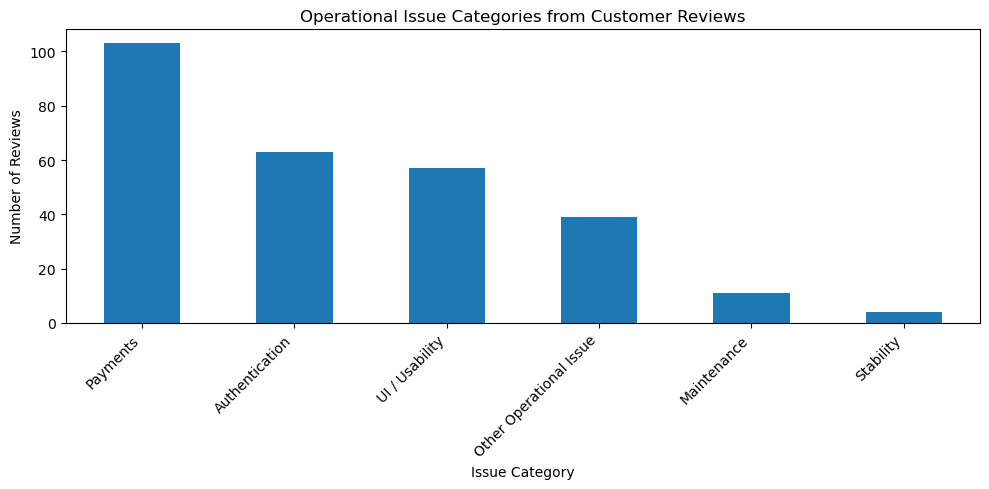

In [9]:
issue_counts.plot(
    kind="bar",
    x="issue_category",
    y="review_count",
    legend=False,
    figsize=(10, 5)
)

plt.title("Operational Issue Categories from Customer Reviews")
plt.xlabel("Issue Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
other_reviews = operational_reviews[
    operational_reviews["issue_category"]
    == "Other Operational Issue"
]

other_reviews[
    ["score", "content"]
].sample(
    min(20, len(other_reviews)),
    random_state=42
)

,score,content
385,1,hard to enter
455,1,I'm trying to sign up and can't find a place t...
72,3,kept messing up during lease singing but other...
193,1,will not hook up
368,1,it will not take me to my area
315,1,will not load
104,1,A whole Unprofessional mess.
319,3,can use this but nothing else
304,2,won't work on the newest galaxy phone now..
216,1,I having problems to open on my phone.


In [11]:
save_classified_reviews(
    operational_reviews,
    "../data/classified_operational_reviews.csv"
)

save_issue_summary(
    issue_counts,
    "../data/issue_category_summary.csv"
)

print("Files saved successfully.")

Files saved successfully.
